In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tell matplotlib to show plots inside the notebook
%matplotlib inline

# Load the dataset (header=1 because row 0 is a title row in this file)
df = pd.read_excel('../data/credit_default.xls', header=1)

# First look at the data
print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())

✅ Dataset loaded successfully!
Shape: 30,000 rows and 25 columns

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [2]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# Checking Variables

In [3]:
# Check target variable (1 = defaulted, 0 = paid)
print("Target distribution:")
print(df['default payment next month'].value_counts())
print("\nDefault rate:", round(df['default payment next month'].mean() * 100, 2), "%")

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Basic stats
df.describe().round(2)

Target distribution:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.12 %

Missing values:
Series([], dtype: int64)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


# Data Cleaning

In [4]:
# ── Step 2: Data Cleaning ──────────────────────────────────────
df = df.drop(columns=['ID'])
df = df.rename(columns={'default payment next month': 'default'})

# Fix undocumented category values
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print("EDUCATION:", df['EDUCATION'].value_counts().sort_index().to_dict())
print("MARRIAGE:", df['MARRIAGE'].value_counts().sort_index().to_dict())
print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())

EDUCATION: {1: 10585, 2: 14030, 3: 4917, 4: 468}
MARRIAGE: {1: 13659, 2: 15964, 3: 377}
Shape: (30000, 24)
Nulls: 0


# Feature Engineering

In [5]:
# ── Step 3: Feature Engineering ────────────────────────────────
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

# 1. Payment delay score — how often was payment late?
df['delay_count'] = (df[pay_cols] > 0).sum(axis=1)

# 2. Max delay — worst late payment in 6 months
df['max_delay'] = df[pay_cols].max(axis=1)

# 3. Average bill amount — proxy for spending level
df['avg_bill'] = df[bill_cols].mean(axis=1)

# 4. Average payment amount
df['avg_pay_amt'] = df[pay_amt_cols].mean(axis=1)

# 5. Payment ratio — how much of their bill do they actually pay?
df['pay_ratio'] = df['avg_pay_amt'] / (df['avg_bill'] + 1)  # +1 avoids division by zero

# 6. Credit utilization — bill vs credit limit
df['utilization'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

# 7. Balance trend — is bill growing or shrinking? (last month vs 6 months ago)
df['bill_trend'] = df['BILL_AMT1'] - df['BILL_AMT6']

print("New features added:")
print(df[['delay_count','max_delay','avg_bill','pay_ratio','utilization','bill_trend']].describe().round(2))

New features added:
       delay_count  max_delay   avg_bill  pay_ratio  utilization  bill_trend
count     30000.00   30000.00   30000.00   29998.00     30000.00    30000.00
mean          0.83       0.44   44976.95       3.77         0.42    12351.57
std           1.55       1.35   63260.72     209.65         0.41    43922.42
min           0.00      -2.00  -56043.17   -1502.00        -0.62  -428791.00
25%           0.00       0.00    4781.33       0.04         0.02    -2963.00
50%           0.00       0.00   21051.83       0.09         0.31      923.00
75%           1.00       2.00   57104.42       0.60         0.83    19793.75
max           6.00       8.00  877313.83   27000.00         6.45   708323.00


# Model Building 

In [6]:
# ── Step 4: Model Building (with NaN fix) ──────────────────────
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# Fix NaN/Inf values created during feature engineering
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

print("NaNs remaining:", df.isnull().sum().sum())  # Should print 0

X = df.drop(columns=['default'])
y = df['default']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE:", y_train_sm.value_counts().to_dict())

# Scale for logistic regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

# ── Model 1: Logistic Regression (baseline) ──
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train_sm)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])
print(f"\nLogistic Regression AUC: {lr_auc:.4f}")

# ── Model 2: XGBoost ──
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                    eval_metric='logloss', random_state=42)
xgb.fit(X_train_sm, y_train_sm)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
print(f"XGBoost AUC:             {xgb_auc:.4f}")

# ── Model 3: LightGBM ──
lgbm = LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                      random_state=42, verbose=-1)
lgbm.fit(X_train_sm, y_train_sm)
lgbm_auc = roc_auc_score(y_test, lgbm.predict_proba(X_test)[:,1])
print(f"LightGBM AUC:            {lgbm_auc:.4f}")

NaNs remaining: 0
After SMOTE: {0: 18691, 1: 18691}

Logistic Regression AUC: 0.7182
XGBoost AUC:             0.7540
LightGBM AUC:            0.7548


# Step 5: Fairness Audit

In [7]:
# ── Step 5: Fairness Audit ─────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Best model predictions
y_pred_proba = lgbm.predict_proba(X_test)[:,1]
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# ── By SEX (1=Male, 2=Female) ──
for sex_val, label in [(1, 'Male'), (2, 'Female')]:
    mask = X_test_reset['SEX'] == sex_val
    auc = roc_auc_score(y_test_reset[mask], y_pred_proba[mask])
    print(f"AUC {label}: {auc:.4f}")

print()

# ── By EDUCATION ──
for edu_val, label in [(1,'Graduate'),(2,'University'),(3,'High School'),(4,'Other')]:
    mask = X_test_reset['EDUCATION'] == edu_val
    auc = roc_auc_score(y_test_reset[mask], y_pred_proba[mask])
    print(f"AUC {label}: {auc:.4f}")

print()

# ── By AGE GROUP ──
X_test_reset['age_group'] = pd.cut(X_test_reset['AGE'],
                                    bins=[20,30,40,50,80],
                                    labels=['21-30','31-40','41-50','51+'])
for grp in ['21-30','31-40','41-50','51+']:
    mask = X_test_reset['age_group'] == grp
    auc = roc_auc_score(y_test_reset[mask], y_pred_proba[mask])
    print(f"AUC Age {grp}: {auc:.4f}")

AUC Male: 0.7492
AUC Female: 0.7610

AUC Graduate: 0.7652
AUC University: 0.7637
AUC High School: 0.7228
AUC Other: 0.5766

AUC Age 21-30: 0.7702
AUC Age 31-40: 0.7529
AUC Age 41-50: 0.7285
AUC Age 51+: 0.7622


# Step 6: SHAP Explainability

C:\credit-scoring-africa\fintech\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


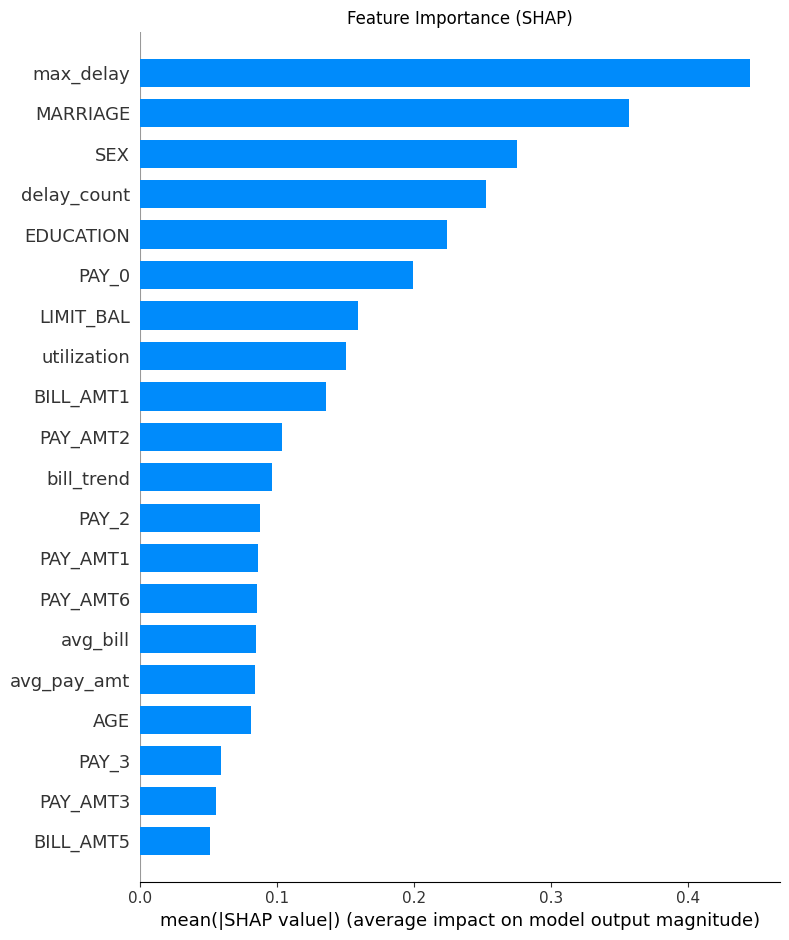

Saved: shap_importance.png


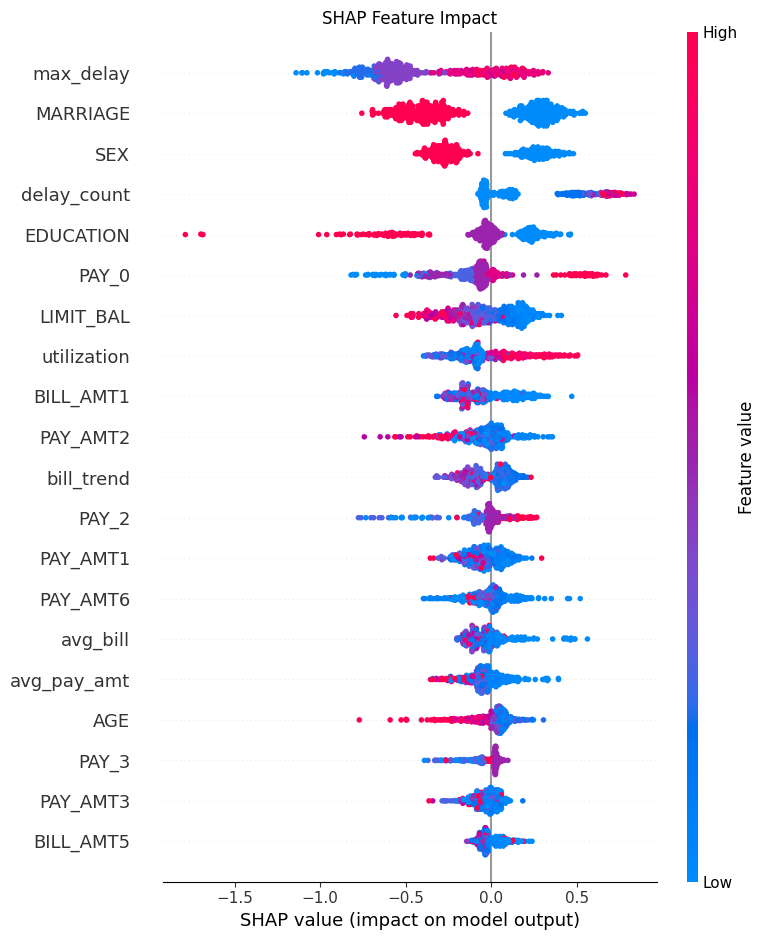

Saved: shap_beeswarm.png


In [8]:
# ── Step 6: SHAP Explainability ────────────────────────────────
import shap
import matplotlib.pyplot as plt

# Compute SHAP values (use a sample for speed)
explainer = shap.TreeExplainer(lgbm)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

# ── Plot 1: Feature Importance (bar) ──
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig('../outputs/shap_importance.png', dpi=150)
plt.show()
print("Saved: shap_importance.png")

# ── Plot 2: SHAP Beeswarm (full impact) ──
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Impact")
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150)
plt.show()
print("Saved: shap_beeswarm.png")

# Save model

In [9]:
# ── Save model ─────────────────────────────────────────────────
import pickle, pandas as pd

# Save model and feature list
with open('../models/lgbm_model.pkl', 'wb') as f:
    pickle.dump(lgbm, f)

feature_cols = X.columns.tolist()
with open('../models/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("Saved! Features:", feature_cols)

Saved! Features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'delay_count', 'max_delay', 'avg_bill', 'avg_pay_amt', 'pay_ratio', 'utilization', 'bill_trend']
